#Import modules

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#Data

In [3]:
rna = pd.read_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/TCGA_Pan_rna_top_variance_genes.csv', index_col = 0)
rna.index.name = None
rna.head(3)

,ENSG00000000005,ENSG00000000419,ENSG00000000971,ENSG00000001617,ENSG00000002549,ENSG00000002586,ENSG00000002726,ENSG00000002834,ENSG00000002933,ENSG00000003989,...,ENSG00000281383,ENSG00000281990,ENSG00000282122,ENSG00000282431,ENSG00000282639,ENSG00000282651,ENSG00000283475,ENSG00000283498,ENSG00000283907,ENSG00000286190
TCGA-D8-A146-01A-31R-A115-07,9.3826,115.1737,30.9154,89.2583,96.8896,200.3364,3.1527,159.0237,64.0686,16.7347,...,2.8579,17.9344,62.3372,5.4955,68.7485,110.661,45.7744,37.2402,0.5340,3.9128
TCGA-AQ-A0Y5-01A-11R-A14M-07,0.3785,134.9047,29.7787,74.5808,66.8669,176.3045,17.2985,162.9267,80.5922,376.5188,...,1.1434,0.0000,0.0000,0.0000,0.0000,0.000,16.0672,33.5950,0.7540,3.4764
TCGA-C8-A274-01A-11R-A16F-07,0.0000,110.8229,6.9632,66.8816,100.7954,71.8287,0.1458,179.6223,15.9810,94.7782,...,1.2957,0.0000,8.1241,0.0000,0.0000,0.000,107.6903,46.5395,0.6518,1.1040


In [4]:
drop_cols = []
for i in rna.columns:
  if i.endswith('.1'):
    drop_cols.append(i)
    print(i)

In [5]:
rna = rna.drop(columns = drop_cols)
for i in rna.columns:
  if i.endswith('.1'):
    print(i)

In [6]:
rna.head(3)

,ENSG00000000005,ENSG00000000419,ENSG00000000971,ENSG00000001617,ENSG00000002549,ENSG00000002586,ENSG00000002726,ENSG00000002834,ENSG00000002933,ENSG00000003989,...,ENSG00000281383,ENSG00000281990,ENSG00000282122,ENSG00000282431,ENSG00000282639,ENSG00000282651,ENSG00000283475,ENSG00000283498,ENSG00000283907,ENSG00000286190
TCGA-D8-A146-01A-31R-A115-07,9.3826,115.1737,30.9154,89.2583,96.8896,200.3364,3.1527,159.0237,64.0686,16.7347,...,2.8579,17.9344,62.3372,5.4955,68.7485,110.661,45.7744,37.2402,0.5340,3.9128
TCGA-AQ-A0Y5-01A-11R-A14M-07,0.3785,134.9047,29.7787,74.5808,66.8669,176.3045,17.2985,162.9267,80.5922,376.5188,...,1.1434,0.0000,0.0000,0.0000,0.0000,0.000,16.0672,33.5950,0.7540,3.4764
TCGA-C8-A274-01A-11R-A16F-07,0.0000,110.8229,6.9632,66.8816,100.7954,71.8287,0.1458,179.6223,15.9810,94.7782,...,1.2957,0.0000,8.1241,0.0000,0.0000,0.000,107.6903,46.5395,0.6518,1.1040


#Log2 transformation

In [7]:
rna = rna.apply(lambda x: np.log2(x + 1))
rna.head(3)

,ENSG00000000005,ENSG00000000419,ENSG00000000971,ENSG00000001617,ENSG00000002549,ENSG00000002586,ENSG00000002726,ENSG00000002834,ENSG00000002933,ENSG00000003989,...,ENSG00000281383,ENSG00000281990,ENSG00000282122,ENSG00000282431,ENSG00000282639,ENSG00000282651,ENSG00000283475,ENSG00000283498,ENSG00000283907,ENSG00000286190
TCGA-D8-A146-01A-31R-A115-07,3.376096,6.860140,4.996181,6.495988,6.613084,7.653464,2.054050,7.322142,6.023890,4.148503,...,1.947816,4.242938,5.984981,2.699441,6.12409,6.802982,5.547647,5.257018,0.617298,2.296546
TCGA-AQ-A0Y5-01A-11R-A14M-07,0.463099,7.086452,4.943860,6.239948,6.084636,7.470085,4.193653,7.356907,6.350359,8.560405,...,1.099901,0.000000,0.000000,0.000000,0.00000,0.000000,4.093154,5.112492,0.810649,2.162339
TCGA-C8-A274-01A-11R-A16F-07,0.000000,6.805072,2.993348,6.084949,6.669529,6.186435,0.196355,7.496832,4.085850,6.581625,...,1.198934,0.000000,3.189682,0.000000,0.00000,0.000000,6.764079,5.571055,0.724039,1.073135


#Data shuffling

In [8]:
shuffled_data = rna.sample(frac=1, random_state=0)
shuffled_rna = shuffled_data[rna.columns]
rna = shuffled_rna
rna.head(3)

,ENSG00000000005,ENSG00000000419,ENSG00000000971,ENSG00000001617,ENSG00000002549,ENSG00000002586,ENSG00000002726,ENSG00000002834,ENSG00000002933,ENSG00000003989,...,ENSG00000281383,ENSG00000281990,ENSG00000282122,ENSG00000282431,ENSG00000282639,ENSG00000282651,ENSG00000283475,ENSG00000283498,ENSG00000283907,ENSG00000286190
TCGA-D1-A17S-01A-11R-A12I-07,0.091124,3.191626,4.091429,4.453392,3.589752,5.177862,2.259785,3.047503,3.870256,0.101785,...,2.009025,0.348006,0.000000,0.000000,0.000000,0.000000,0.000000,2.962790,5.292800,1.191373
TCGA-24-1564-01A-01R-1566-13,0.055057,8.350674,6.165472,5.339259,6.971360,6.369138,5.840947,6.970767,7.474835,4.852059,...,3.651832,0.000000,0.000000,0.000000,0.406319,0.189034,3.476550,7.596157,6.793648,3.569224
TCGA-BR-6456-01A-11R-1802-13,0.814099,6.640239,5.079698,5.504249,6.484088,7.062474,6.964773,7.806433,8.254657,2.533040,...,3.708209,4.344175,3.586092,3.777977,5.929554,6.244461,1.762944,5.442688,6.496362,3.571240


#Data imputation and normalization [-1, 1]

In [9]:
from sklearn.impute import SimpleImputer

def impute_normalize(df):
  data = df.copy()
  imputer = SimpleImputer(strategy='median')
  data = imputer.fit_transform(data)
  min_val = np.min(data)
  max_val = np.max(data)
  data_scaled = 2 * ((data - min_val) / (max_val - min_val)) - 1
  data_scaled = data_scaled.astype(np.float32)
  print('min:', np.min(data_scaled))
  print('max:', np.max(data_scaled))
  print('shape:', data_scaled.shape)

  return data_scaled

#Neural network

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [11]:
X = rna.drop(labels = ['ENSG00000211592'], axis = 'columns')
y = rna[['ENSG00000211592']]

In [12]:
input_features = X.columns.tolist()
input_features

['ENSG00000000005',
 'ENSG00000000419',
 'ENSG00000000971',
 'ENSG00000001617',
 'ENSG00000002549',
 'ENSG00000002586',
 'ENSG00000002726',
 'ENSG00000002834',
 'ENSG00000002933',
 'ENSG00000003989',
 'ENSG00000004059',
 'ENSG00000004142',
 'ENSG00000004478',
 'ENSG00000004776',
 'ENSG00000004779',
 'ENSG00000004799',
 'ENSG00000004939',
 'ENSG00000005022',
 'ENSG00000005075',
 'ENSG00000005421',
 'ENSG00000005486',
 'ENSG00000005513',
 'ENSG00000005884',
 'ENSG00000006016',
 'ENSG00000006125',
 'ENSG00000006128',
 'ENSG00000006210',
 'ENSG00000006327',
 'ENSG00000006659',
 'ENSG00000006831',
 'ENSG00000007080',
 'ENSG00000007255',
 'ENSG00000007306',
 'ENSG00000007312',
 'ENSG00000007350',
 'ENSG00000007933',
 'ENSG00000007952',
 'ENSG00000008018',
 'ENSG00000008282',
 'ENSG00000008283',
 'ENSG00000008394',
 'ENSG00000008441',
 'ENSG00000008517',
 'ENSG00000008988',
 'ENSG00000009307',
 'ENSG00000009765',
 'ENSG00000010256',
 'ENSG00000010278',
 'ENSG00000010438',
 'ENSG00000010610',


In [13]:
import pickle

with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/ENSG00000211592_unbiased_features_nn_model_input_features.pkl', 'wb') as f:
  pickle.dump(input_features, f)

In [14]:
X = X.values
y = y.values

In [15]:
print(X.shape)
print(y.shape)

(10668, 3030)
(10668, 1)


In [16]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.1, random_state = 0)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = 0)

X_train = impute_normalize(X_train)
X_test = impute_normalize(X_test)
X_val = impute_normalize(X_val)
y_train = impute_normalize(y_train)
y_test = impute_normalize(y_test)
y_val = impute_normalize(y_val)

print('Train data:')
print(X_train.shape)
print(y_train.shape)

print('Test data:')
print(X_test.shape)
print(y_test.shape)

print('Val data:')
print(X_val.shape)
print(y_val.shape)

min: -1.0
max: 1.0
shape: (9601, 3030)
min: -1.0
max: 1.0
shape: (533, 3030)
min: -1.0
max: 1.0
shape: (534, 3030)
min: -1.0
max: 1.0
shape: (9601, 1)
min: -1.0
max: 1.0
shape: (533, 1)
min: -1.0
max: 1.0
shape: (534, 1)
Train data:
(9601, 3030)
(9601, 1)
Test data:
(533, 3030)
(533, 1)
Val data:
(534, 3030)
(534, 1)


In [17]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dropout


model = keras.Sequential([
    layers.Input(shape = (X_train.shape[1],)),
    layers.Dense(1024, activation = 'relu'),
    BatchNormalization(),
    Dropout(0.5),

    layers.Dense(512, activation = 'relu'),
    BatchNormalization(),
    Dropout(0.5),

    layers.Dense(256, activation = 'relu'),
    BatchNormalization(),
    Dropout(0.5),

    keras.layers.Dense(1, activation='linear')
])

In [18]:
model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │     3,103,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,767,297 (14.37 MB)

 Trainable params: 3,763,713 (14.36 MB)

 Non-trainable params: 3,584 (14.00 KB)

In [19]:
history = model.fit(X_train, y_train,
                    epochs=1000,
                    batch_size=32,
                    validation_data=(X_val, y_val),
                    shuffle = True,
                    callbacks=[tf.keras.callbacks.EarlyStopping(patience=100, restore_best_weights=True)]
                    )

Epoch 1/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 2.1900 - mae: 1.0959 - val_loss: 0.1536 - val_mae: 0.2206
Epoch 2/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2577 - mae: 0.3767 - val_loss: 0.0183 - val_mae: 0.1022
Epoch 3/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0559 - mae: 0.1777 - val_loss: 0.0158 - val_mae: 0.0933
Epoch 4/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0295 - mae: 0.1314 - val_loss: 0.0139 - val_mae: 0.0868
Epoch 5/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0246 - mae: 0.1173 - val_loss: 0.0089 - val_mae: 0.0681
Epoch 6/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0221 - mae: 0.1125 - val_loss: 0.0090 - val_mae: 0.0705
Epoch 7/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0232 - mae: 0.1147 - val_loss: 0.0102 - val_mae: 0.0767
Epoch 8/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0205 - mae: 0.1078 - val_loss: 0.0113 - val_mae: 0.0785
Epoch 9/1000
301/301 ━━━━━━━━━━━━━━━━━━

In [20]:
model.save('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/ENSG00000211592_unbiased_features_nn_model.keras')

In [21]:
loss, mae = model.evaluate(X_test, y_test, verbose=1)
print("Mean Absolute Error:", mae)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0034 - mae: 0.0450
Mean Absolute Error: 0.04684709385037422


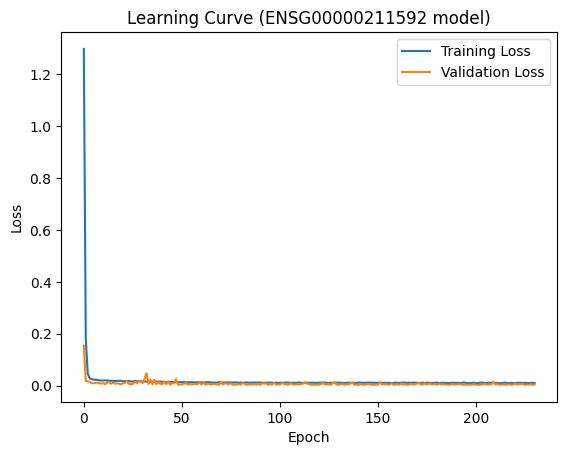

In [22]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Learning Curve (ENSG00000211592 model)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/ENSG00000211592_unbiased_features_learning_curve.svg', bbox_inches = 'tight')
plt.show()

In [23]:
train_loss = history.history['loss'][-1]
train_mae = history.history['mae'][-1]
print(f"Training Loss: {train_loss:.4f}")
print(f"Training MAE: {train_mae:.4f}")

Training Loss: 0.0101
Training MAE: 0.0790


In [24]:
val_loss = history.history['val_loss'][-1]
val_mae = history.history['val_mae'][-1]
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation MAE: {val_mae:.4f}")

Validation Loss: 0.0046
Validation MAE: 0.0506


In [25]:
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test MAE: {mae:.4f}")

Test Loss: 0.0041
Test MAE: 0.0468


In [26]:
predictions = model.predict(X_test)

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


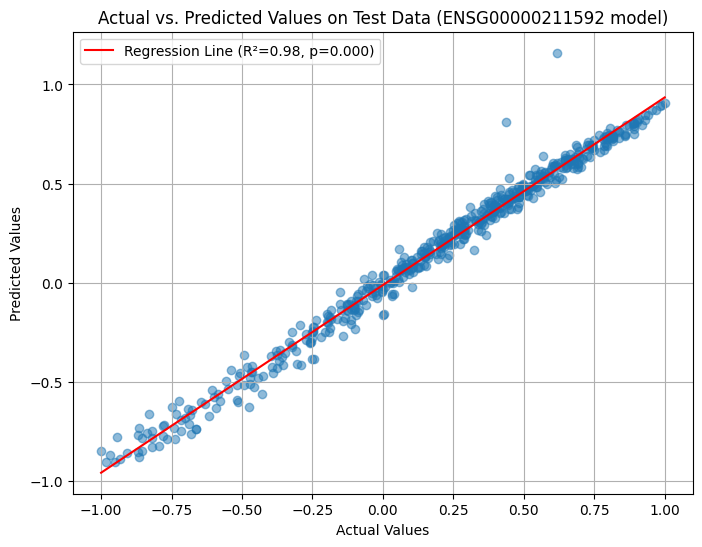

R-squared: 0.9848
P-value: 0.0000


In [27]:
from scipy.stats import linregress
import matplotlib.pyplot as plt
import numpy as np

# Calculate the regression line and statistics
slope, intercept, r_value, p_value, std_err = linregress(y_test.flatten(), predictions.flatten())

plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5)

x_values = np.array([y_test.min(), y_test.max()])
plt.plot(x_values, intercept + slope * x_values, color='red', label=f'Regression Line (R²={r_value**2:.2f}, p={p_value:.3f})')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values on Test Data (ENSG00000211592 model)")
plt.grid(True)
plt.legend()
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/ENSG00000211592_unbiased_features_Reg_plot_actual_pred_.svg', bbox_inches = 'tight')
plt.show()

print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.4f}")